In [1]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

import warnings

warnings.filterwarnings(
    "ignore",
    message="FutureWarning: job_extra has been renamed to job_extra_directives.*",
    category=UserWarning
)

In [2]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
cluster = SLURMCluster(
    memory="100GB",
    processes=8,
    cores=8,
    walltime="02:00:00",
    queue="dcgp_usr_prod",
    account="ICT26_ESP",
    interface="ib0",
    env_extra=[
        "export OMP_NUM_THREADS=1",
        "export MKL_NUM_THREADS=1",
        "export NUMBA_NUM_THREADS=1",
    ],
    job_extra=[
        "--nodes=1",
        "--ntasks-per-node=8",
        "--hint=nomultithread",
    ],
    log_directory="logs/"
)

cluster.scale(16)
client = Client(cluster)

client

/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Futu

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.128.0.1:8787/status,
Dashboard: http://10.128.0.1:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.128.0.1:46603,Workers: 0
Dashboard: http://10.128.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
%%time 

experiment = 'AccessOm2RYF_SPEEDY'

CPU times: user 8 μs, sys: 2 μs, total: 10 μs
Wall time: 22.9 μs


In [4]:
%%time 
CATALOG = "/leonardo/home/userexternal/ntilinin/access-om2-catalog/AccessOm2RYF_SPEEDY.json"

catalog = intake.open_esm_datastore(
    CATALOG,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

catalog

CPU times: user 982 ms, sys: 94.5 ms, total: 1.08 s
Wall time: 1.25 s


,unique
filename,3964
file_id,94
path,3964
filename_timestamp,3236
frequency,2
start_date,3134
end_date,3134
variable,223
variable_long_name,203
variable_standard_name,38


In [5]:
variable = "net_sfc_heating"

ds = catalog.search(
    variable=variable,
    frequency="1mon"
).to_dask()

shflux = ds[variable]

print("dims:", shflux.dims)
print("units:", shflux.attrs.get("units"))
print("time:", shflux.time.min().values, "→", shflux.time.max().values)

dims: ('time', 'yt_ocean', 'xt_ocean')
units: Watts/m^2
time: 1900-01-16 12:00:00 → 1907-12-16 12:00:00


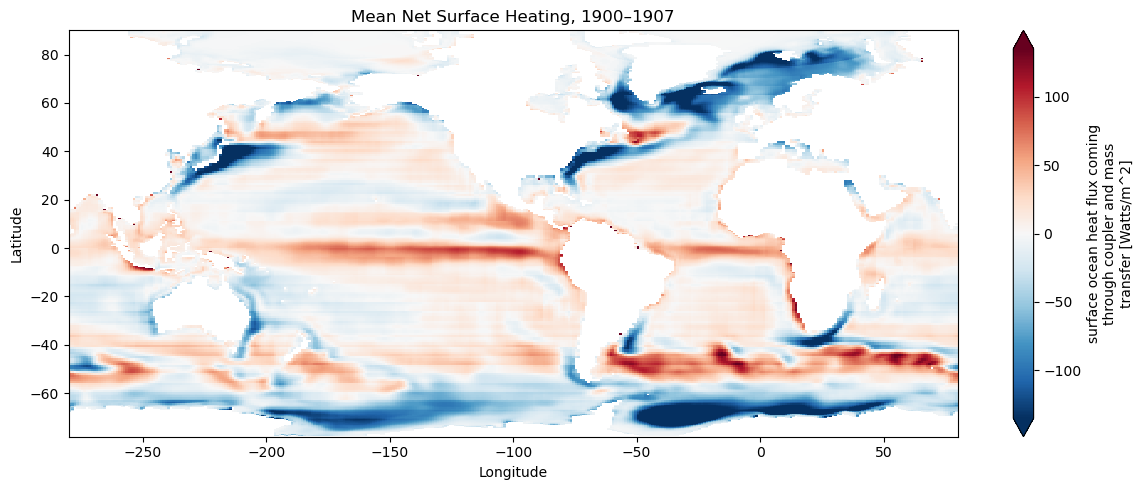

In [13]:
shflux_mean = shflux.mean("time")

fig, ax = plt.subplots(figsize=(12, 5))

shflux_mean.plot(
    ax=ax,
    cmap="RdBu_r",
    center=0,
    robust=True
)

ax.set_title("Net Surface Heat Flux, 1900–1907")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [14]:
shflux_ann = shflux.groupby("time.year").mean("time")

q1900 = shflux_ann.sel(year=1900)
q1907 = shflux_ann.sel(year=1907)
qdiff = q1907 - q1900

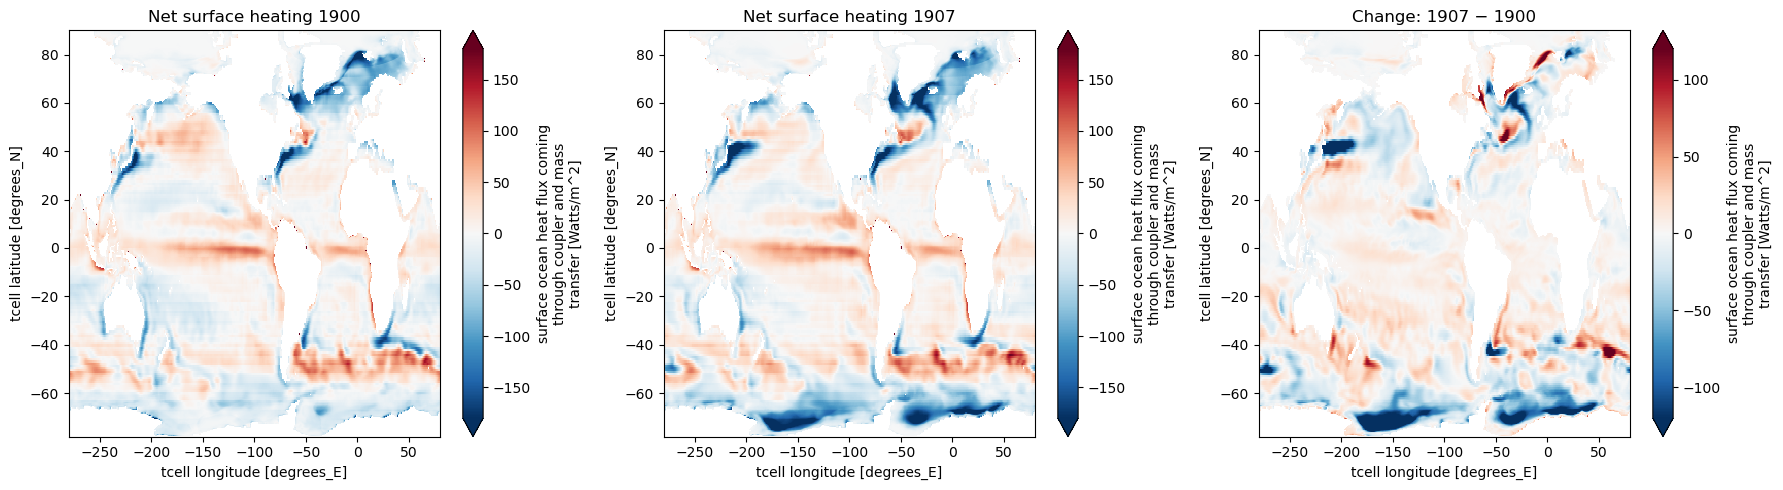

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

q1900.plot(ax=axs[0], cmap="RdBu_r", vmin=-180, vmax=180)
axs[0].set_title("Net surface heating 1900")

q1907.plot(ax=axs[1], cmap="RdBu_r", vmin=-180, vmax=180)
axs[1].set_title("Net surface heating 1907")

qdiff.plot(ax=axs[2], cmap="RdBu_r", vmin=-120, vmax=120)
axs[2].set_title("Change: 1907 − 1900")

plt.tight_layout()

In [18]:
GRID_PATH = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/1deg_jra55_ryf_configured/archive/1deg_jra55_ryf_5yr/output005/ocean"

area = xr.open_dataset(
    f"{GRID_PATH}/ocean-2d-area_t.nc"
)["area_t"]

area

<xarray.DataArray 'area_t' (yt_ocean: 300, xt_ocean: 360)> Size: 432kB
[108000 values with dtype=float32]
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:     tracer cell area
    units:         m^2
    valid_range:   [0.e+00 1.e+15]
    cell_methods:  time: point

In [20]:
weights = area.where(shflux_ann.isel(year=0).notnull(), 0)

shflux_global = shflux_ann.weighted(weights).mean(
    ("yt_ocean", "xt_ocean")
)

for year, value in zip(shflux_global.year.values, shflux_global.values):
    print(f"{year}: {value:.3f} W/m²")

1900: 0.074 W/m²
1901: 1.299 W/m²
1902: -0.260 W/m²
1903: -1.000 W/m²
1904: -1.308 W/m²
1905: -1.425 W/m²
1906: -1.313 W/m²
1907: -0.986 W/m²


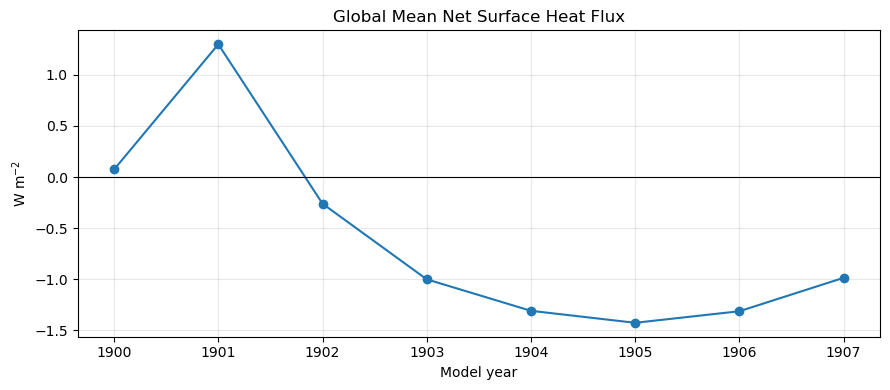

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

shflux_global.plot(ax=ax, marker="o")

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Global Mean Net Surface Heat Flux")
ax.set_xlabel("Model year")
ax.set_ylabel("W m$^{-2}$")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
print(shflux.attrs)

{'long_name': 'surface ocean heat flux coming through coupler and mass transfer', 'units': 'Watts/m^2', 'valid_range': array([-10000.,  10000.], dtype=float32), 'cell_methods': 'time: mean', 'time_avg_info': 'average_T1,average_T2,average_DT'}
